In [1]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write('{"username":"nauvalsainsdataunesa","key":"3909a8d8d095fb4a9a2ca24c734870d1"}')
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

!pip install -q kaggle
!kaggle datasets download -d pythonafroz/solar-panel-images --unzip -p solar-panel-images

print("Contents of solar-panel-images:", os.listdir("solar-panel-images"))

Dataset URL: https://www.kaggle.com/datasets/pythonafroz/solar-panel-images
License(s): unknown


  0%|                                                | 0.00/305M [00:00<?, ?B/s]

 66%|██████████████████████████▏             | 200M/305M [00:00<00:00, 2.09GB/s]


100%|████████████████████████████████████████| 305M/305M [00:00<00:00, 2.16GB/s]


Contents of solar-panel-images: ['Faulty_solar_panel']


### 1. Download dan eksplorasi dataset (EDA)

/tmp/ipykernel_873334/3796134089.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette='viridis')


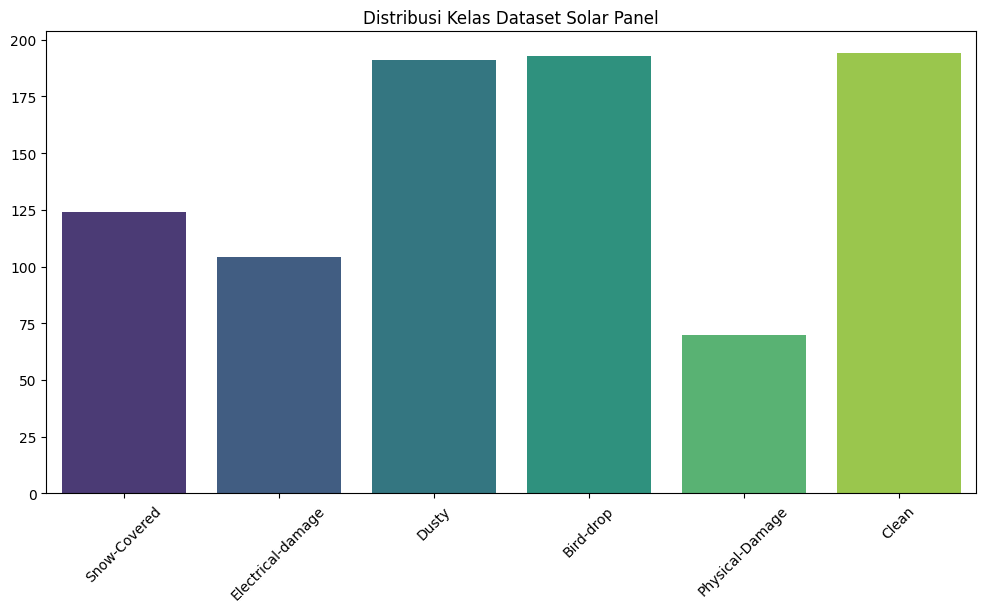

Jumlah Data: {'Snow-Covered': 124, 'Electrical-damage': 104, 'Dusty': 191, 'Bird-drop': 193, 'Physical-Damage': 70, 'Clean': 194}


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Updated path based on common Kaggle dataset structures
dataset_path = 'solar-panel-images/Faulty_solar_panel/Faulty_solar_panel'
if not os.path.exists(dataset_path):
    dataset_path = 'solar-panel-images/Faulty_solar_panel'

categories = [c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))]
stats = {cat: len(os.listdir(os.path.join(dataset_path, cat))) for cat in categories}

plt.figure(figsize=(12, 6))
sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette='viridis')
plt.title('Distribusi Kelas Dataset Solar Panel')
plt.xticks(rotation=45)
plt.show()

print("Jumlah Data:", stats)

### 2. Cek distribusi kelas

In [3]:
!pip install -q split-folders
import splitfolders
import os

input_folder = 'solar-panel-images/Faulty_solar_panel/Faulty_solar_panel'
if not os.path.exists(input_folder):
    input_folder = 'solar-panel-images/Faulty_solar_panel'

output_folder = 'dataset_split'

# Split 80% Train, 10% Val, 10% Test
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .1, .1), group_prefix=None, move=False)

Copying files: 0 files [00:00, ? files/s]

Copying files: 431 files [00:00, 4306.65 files/s]

Copying files: 862 files [00:00, 4008.40 files/s]

Copying files: 875 files [00:00, 4039.03 files/s]

### 3. Split data train/validation/test

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

I0000 00:00:1779279899.822464  873334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779279899.823046  873334 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1779279899.857186  873334 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/usr/local/lib/python3.10/dist-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


I0000 00:00:1779279901.086940  873334 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779279901.087348  873334 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 693 images belonging to 6 classes.


Found 85 images belonging to 6 classes.


Found 91 images belonging to 6 classes.


### 4. Resize, normalisasi, augmentasi gambar

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

E0000 00:00:1779279901.403023  873334 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10


I0000 00:00:1779279902.886151  873334 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


 1/22 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.1875 - loss: 2.0671

 2/22 ━━━━━━━━━━━━━━━━━━━━ 7s 358ms/step - accuracy: 0.1875 - loss: 2.1747

 3/22 ━━━━━━━━━━━━━━━━━━━━ 8s 436ms/step - accuracy: 0.1910 - loss: 2.1713

...

19/22 ━━━━━━━━━━━━━━━━━━━━ 1s 404ms/step - accuracy: 0.7423 - loss: 0.6826

20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.7435 - loss: 0.6798

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7443 - loss: 0.6778

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7452 - loss: 0.6760

22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 0.7633 - loss: 0.6384 - val_accuracy: 0.6706 - val_loss: 0.8596


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10


 1/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.2188 - loss: 2.1663

 2/22 ━━━━━━━━━━━━━━━━━━━━ 8s 411ms/step - accuracy: 0.2422 - loss: 2.1478

 3/22 ━━━━━━━━━━━━━━━━━━━━ 9s 478ms/step - accuracy: 0.2552 - loss: 2.1500

 4/22 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.2656 - loss: 2.1434

...

19/22 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - accuracy: 0.7797 - loss: 0.6388

20/22 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7793 - loss: 0.6389

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.7788 - loss: 0.6392

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.7785 - loss: 0.6394

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 488ms/step - accuracy: 0.7720 - loss: 0.6422 - val_accuracy: 0.7294 - val_loss: 0.8074


5. Load Pre-trained CNN Model (VGG16)

In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

x = Flatten()(base_model.output)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=x
)

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

6. Ekstraksi fitur gambar menggunakan CNN

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input


dataset_path = "solar-panel-images/Faulty_solar_panel"


datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

data_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

features = feature_extractor.predict(data_generator)
print("Shape fitur:", features.shape)

Found 885 images belonging to 6 classes.


 1/28 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step

 2/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step

 3/28 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step

 4/28 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step

...

26/28 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step

27/28 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step


Shape fitur: (885, 25088)


7. Simpan vektor fitur hasil ekstraksi sebagai input ensemble

In [11]:
import numpy as np

np.save("fitur_cnn.npy", features)

print("Feature vector berhasil disimpan!")

Feature vector berhasil disimpan!


### 8. Evaluasi Model (Classification Report + F1 Score)

In [12]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Prediksi pada test set
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Metrik
acc = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average="weighted")
f1_macro = f1_score(y_true, y_pred, average="macro")

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)
print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro)   : {f1_macro:.4f}")
print("="*60)

1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step


CLASSIFICATION REPORT
                   precision    recall  f1-score   support

        Bird-drop       0.69      0.45      0.55        20
            Clean       0.61      0.85      0.71        20
            Dusty       0.65      0.85      0.74        20
Electrical-damage       0.82      0.82      0.82        11
  Physical-Damage       1.00      0.43      0.60         7
     Snow-Covered       1.00      0.77      0.87        13

         accuracy                           0.71        91
        macro avg       0.80      0.69      0.71        91
     weighted avg       0.75      0.71      0.71        91

Test Accuracy : 0.7143 (71.43%)
F1 Score (weighted): 0.7073
F1 Score (macro)   : 0.7134


### 9. Visualisasi Grafik Training vs Validation

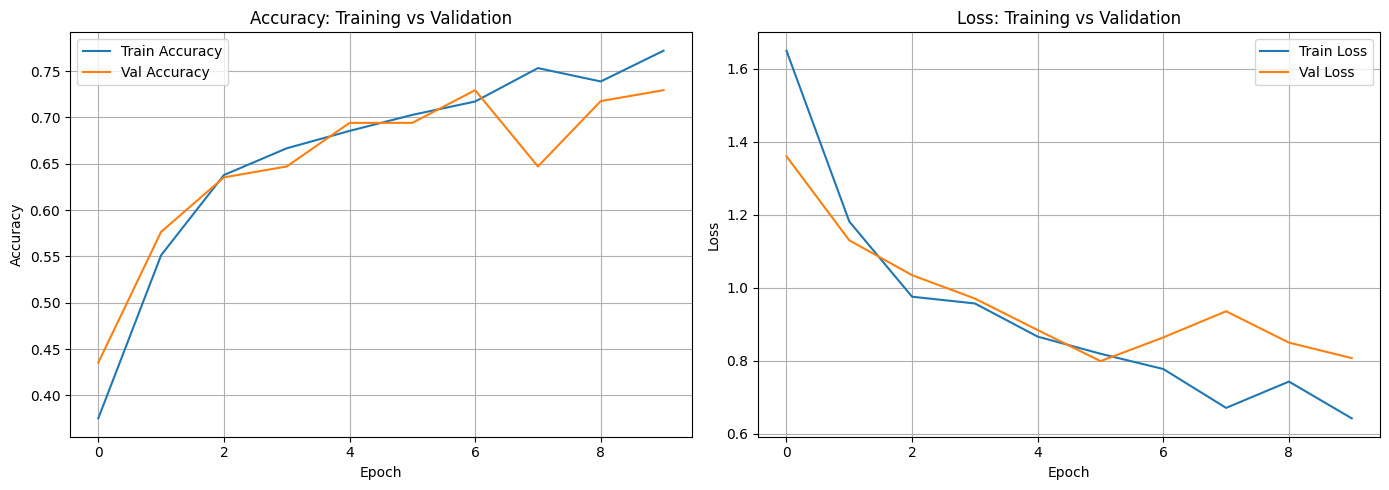

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy: Training vs Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss: Training vs Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 10. Hyperparameter Tuning

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# === HYPERPARAMETER TUNING: Fine-tune last layers ===
# Find the MobileNetV2 base model
base = None
for layer in model.layers:
    if hasattr(layer, "layers") and len(layer.layers) > 10:
        base = layer
        break

if base:
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    print(f"Fine-tuning {sum(1 for l in base.layers if l.trainable)} layers")
else:
    # Fallback: unfreeze all
    for layer in model.layers:
        layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)
]

print("Memulai fine-tuning...")

history_ft = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

Memulai fine-tuning...


Epoch 1/20


 1/22 ━━━━━━━━━━━━━━━━━━━━ 4:05 12s/step - accuracy: 0.4375 - loss: 1.5844

 2/22 ━━━━━━━━━━━━━━━━━━━━ 17s 878ms/step - accuracy: 0.4688 - loss: 1.6019

 3/22 ━━━━━━━━━━━━━━━━━━━━ 16s 846ms/step - accuracy: 0.4722 - loss: 1.5813

...

19/22 ━━━━━━━━━━━━━━━━━━━━ 2s 829ms/step - accuracy: 0.6288 - loss: 1.0883

20/22 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step - accuracy: 0.6278 - loss: 1.0909

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.6270 - loss: 1.0933

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.6261 - loss: 1.0959

22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 868ms/step - accuracy: 0.6075 - loss: 1.1497 - val_accuracy: 0.6941 - val_loss: 0.9752 - learning_rate: 5.0000e-06


In [15]:
# === Evaluasi setelah Hyperparameter Tuning ===
test_generator.reset()
y_pred_probs_ft = model.predict(test_generator)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

acc_ft = accuracy_score(y_true, y_pred_ft)
f1_ft = f1_score(y_true, y_pred_ft, average="weighted")

print("="*60)
print("HASIL SETELAH HYPERPARAMETER TUNING (Fine-Tuning)")
print("="*60)
print(classification_report(y_true, y_pred_ft, target_names=class_names))
print(f"Test Accuracy : {acc_ft:.4f} ({acc_ft*100:.2f}%)")
print(f"F1 Score (weighted): {f1_ft:.4f}")
print("="*60)
print(f"\n--- Perbandingan ---")
print(f"Sebelum tuning: Acc={acc:.4f}, F1={f1_weighted:.4f}")
print(f"Setelah tuning: Acc={acc_ft:.4f}, F1={f1_ft:.4f}")

1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step


HASIL SETELAH HYPERPARAMETER TUNING (Fine-Tuning)
                   precision    recall  f1-score   support

        Bird-drop       0.67      0.50      0.57        20
            Clean       0.57      0.85      0.68        20
            Dusty       0.71      0.85      0.77        20
Electrical-damage       0.82      0.82      0.82        11
  Physical-Damage       1.00      0.14      0.25         7
     Snow-Covered       1.00      0.77      0.87        13

         accuracy                           0.70        91
        macro avg       0.79      0.66      0.66        91
     weighted avg       0.75      0.70      0.69        91

Test Accuracy : 0.7033 (70.33%)
F1 Score (weighted): 0.6872

--- Perbandingan ---
Sebelum tuning: Acc=0.7143, F1=0.7073
Setelah tuning: Acc=0.7033, F1=0.6872


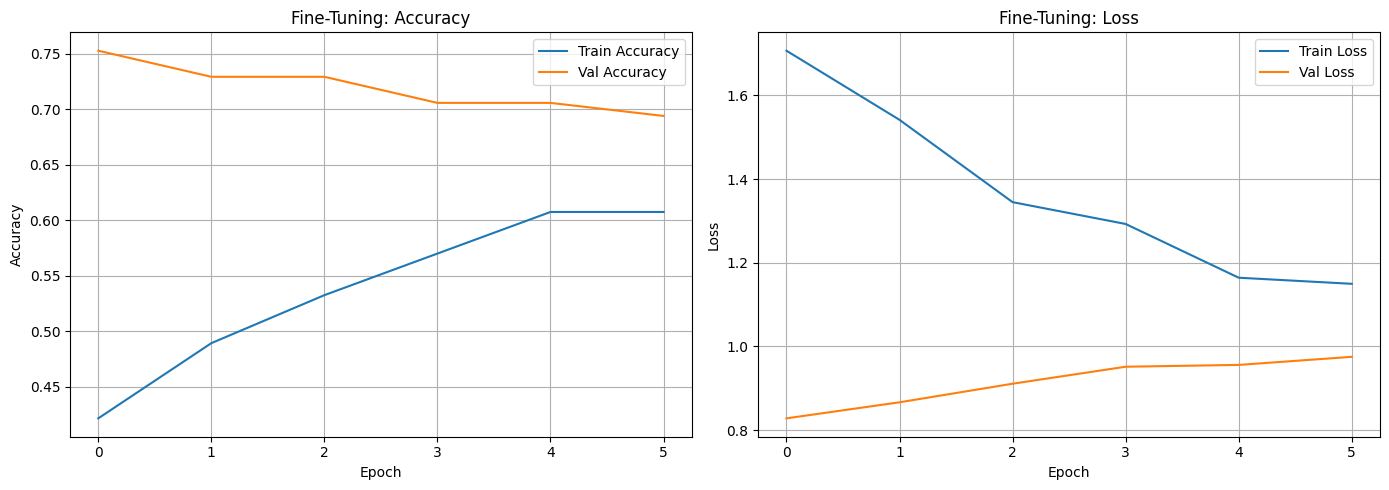

In [16]:
# Plot fine-tuning history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ft.history["accuracy"], label="Train Accuracy")
axes[0].plot(history_ft.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Fine-Tuning: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_ft.history["loss"], label="Train Loss")
axes[1].plot(history_ft.history["val_loss"], label="Val Loss")
axes[1].set_title("Fine-Tuning: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()